# NBA Home Court Bias Analysis

The purpose of this analyis is to....

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [4]:
#Upload Paths 
nba = pd.read_csv('/Users/pcn08/Desktop/Projects_Git/Home_Court_Bias/Historical_NBA.csv')
team_map = pd.read_csv('/Users/pcn08/Desktop/Projects_Git/Home_Court_Bias/team_city_map.csv')
nba.columns = nba.columns.str.strip().str.lower().str.replace(' ', '_')
nba.info()
nba.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gameorder      126314 non-null  int64  
 1   game_id        126314 non-null  object 
 2   lg_id          126314 non-null  object 
 3   _iscopy        126314 non-null  int64  
 4   year_id        126314 non-null  int64  
 5   date_game      126314 non-null  object 
 6   seasongame     126314 non-null  int64  
 7   is_playoffs    126314 non-null  int64  
 8   team_id        126314 non-null  object 
 9   fran_id        126314 non-null  object 
 10  pts            126314 non-null  int64  
 11  elo_i          126314 non-null  float64
 12  elo_n          126314 non-null  float64
 13  win_equiv      126314 non-null  float64
 14  opp_id         126314 non-null  object 
 15  opp_fran       126314 non-null  object 
 16  opp_pts        126314 non-null  int64  
 17  opp_elo_i      126314 non-nul

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN


In [ ]:
games['date_game'] = pd.to_datetime(games.get('date_game', pd.NaT), errors='coerce')
games = games[games['game_location'].isin(['H','A'])].copy()     # drop neutral
games['score_diff'] = games['pts'] - games['opp_pts']            # team margin
games['win'] = (games['score_diff'] > 0).astype(int)

In [5]:
# Filter to regular season
nba = nba[nba['is_playoffs'] == 0]

# Create home/away + win/loss flags
nba['home'] = nba['game_location'].apply(lambda x: 1 if x == 'H' else 0)
nba['win'] = nba['game_result'].apply(lambda x: 1 if x == 'W' else 0)

# Point differential (team - opponent)
nba['score_diff'] = nba['pts'] - nba['opp_pts']

# Quick check
nba[['year_id','home','win','score_diff']].head()

,year_id,home,win,score_diff
0,1947,1,0,-2
1,1947,0,1,2
2,1947,1,1,16
3,1947,0,0,-16
4,1947,1,0,-17


In [6]:
home_summary = (
    nba.groupby('year_id')
       .agg(home_win_rate=('win', lambda x: x[nba.loc[x.index, 'home']==1].mean()),
            away_win_rate=('win', lambda x: x[nba.loc[x.index, 'home']==0].mean()),
            avg_home_margin=('score_diff', lambda x: (x[nba.loc[x.index, 'home']==1]).mean()))
       .reset_index()
)
home_summary.head()

,year_id,home_win_rate,away_win_rate,avg_home_margin
0,1947,0.613293,0.386707,2.422961
1,1948,0.567708,0.432292,1.755208
2,1949,0.611111,0.388889,3.208333
3,1950,0.657754,0.342246,5.030303
4,1951,0.725989,0.274011,6.505650


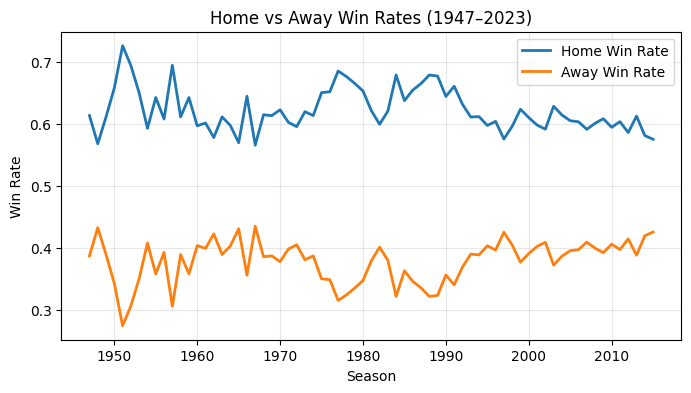

In [7]:
#Home vs. Away Win Rates
plt.figure(figsize=(8,4))
plt.plot(home_summary['year_id'], home_summary['home_win_rate'], label='Home Win Rate', lw=2)
plt.plot(home_summary['year_id'], home_summary['away_win_rate'], label='Away Win Rate', lw=2)
plt.title('Home vs Away Win Rates (1947–2023)')
plt.xlabel('Season')
plt.ylabel('Win Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
import statsmodels.api as sm

df = nba[['score_diff','home']].dropna()
X = sm.add_constant(df['home'])
y = df['score_diff']
model = sm.OLS(y, X).fit()
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6931      0.053    -69.763      0.000      -3.797      -3.589
home           7.3885      0.075     98.676      0.000       7.242       7.535


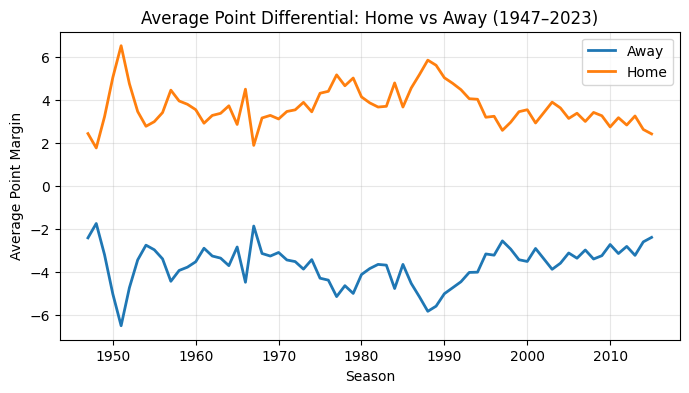

In [9]:
# Average score differential by year and location
diff_summary = (
    nba.groupby(['year_id', 'home'])
       .agg(avg_margin=('score_diff', 'mean'))
       .reset_index()
)

# Plot
plt.figure(figsize=(8,4))
for label, df_sub in diff_summary.groupby('home'):
    label_name = 'Home' if label == 1 else 'Away'
    plt.plot(df_sub['year_id'], df_sub['avg_margin'], label=label_name, lw=2)

plt.title('Average Point Differential: Home vs Away (1947–2023)')
plt.xlabel('Season')
plt.ylabel('Average Point Margin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Filter out missing values
df = nba[['score_diff', 'home', 'year_id']].dropna()

# Add constant for intercept
X = sm.add_constant(df['home'])
y = df['score_diff']

# OLS regression
model = sm.OLS(y, X).fit()

# Display key coefficients
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6931      0.053    -69.763      0.000      -3.797      -3.589
home           7.3885      0.075     98.676      0.000       7.242       7.535


In [11]:
import statsmodels.api as sm

X = sm.add_constant(nba[['home','elo_i','forecast']])
y = nba['pts'] - nba['opp_pts']  # point margin
model = sm.OLS(y, X).fit()
print(model.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.0266      0.568    -28.230      0.000     -17.139     -14.914
home           0.4028      0.092      4.374      0.000       0.222       0.583
elo_i          0.0008      0.000      1.977      0.048    7.14e-06       0.002
forecast      29.1678      0.258    113.184      0.000      28.663      29.673
